# Shendure MWU p-value calibration — all cell types

Checks that MWU p-values are well-calibrated under the null hypothesis.

All synthetic CREs are assigned the **same activity as the reference** (minP),
so every comparison is truly null. Under correct calibration, p-values should
be Uniform(0,1).

For each cell type:
1. Draw `n_cres` synthetic CREs all at `minP` (null ground truth)
2. Simulate using empirical cell counts and bounds, 20 library reps × 5 sim reps
3. Run MWU for all CREs vs. reference
4. Plot p-value histograms, QQ plots, and empirical FPR at α=0.05

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import uuid

In [2]:
data_root = Path("/gpfs/gibbs/pi/reilly/tabula_data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
sim_date = "2026-03-23"

In [3]:
local = False
if local:
    cluster = LocalCluster(memory_limit='48G')
    client = Client(cluster)
else:
    cluster = SLURMCluster(
        cores=3,
        memory="16G",
        processes=3,
        worker_extra_args=["--nthreads", "2"],
        job_extra_directives=[
            "-p ycga",
            "--job-name=simclust_worker",
            "--time=6:00:00",
            "--output=worker_%j.out"
        ]
    )
    cluster.scale(jobs=10)
    client = Client(
        cluster,
        timeout=f"{5*60}s",
        heartbeat_interval="20s"
    )
print(client.dashboard_link, flush=True)

http://10.178.138.9:8787/status


In [4]:
# Get per-cell-type n_cres from the ortho's by_cell_type parameters.
# (Avoids loading the full ortho, whose training_data pickle contains
# lazy file references to the Roberts cluster.)
import pickle
with open(data_root / "shendure" / "shendure_ortho_20260306" / "by_cell_type_parameters.pkl", "rb") as f:
    _params = pickle.load(f)

n_cres_per_ct = {ct: len(_params.nb[ct]) for ct in _params.nb}
cell_types = sorted(n_cres_per_ct.keys())
del _params

print("Cell types and parameters:")
for ct in cell_types:
    cells = scm.SHENDURE_BOUNDS.cells_per_cell_type.get(ct, "N/A")
    print(f"  {ct}: n_cres={n_cres_per_ct[ct]}, cells={cells}")

Cell types and parameters:
  Cardiomyocytes: n_cres=79, cells=680
  EpiblastPrimitiveStreak: n_cres=185, cells=3445
  ExEndodermParietal: n_cres=178, cells=4644
  ExEndodermVisceral: n_cres=148, cells=3238
  Haematoendothelial: n_cres=91, cells=1079
  Mesoderm: n_cres=177, cells=7427
  NeuroectodermBrain: n_cres=173, cells=7750
  NeuroectodermRostral: n_cres=85, cells=1757
  SurfaceEctoderm: n_cres=139, cells=5168
  reference: n_cres=207, cells=8201


In [5]:
minP = scm.SHENDURE_BOUNDS.reference_activity
n_library_reps = 20
n_sims = 5
print(f"minP={minP:.6f}, n_library_reps={n_library_reps}, n_sims={n_sims}")

minP=0.019311, n_library_reps=20, n_sims=5


In [6]:
all_sims = {}  # {cell_type: [sim, ...]}

for cell_type in cell_types:
    print(f"\n=== {cell_type} ===", flush=True)

    bound_ct = scm.SHENDURE_BOUNDS.copy()
    bound_ct.cells_per_cell_type = scm.SHENDURE_BOUNDS.cells_per_cell_type.loc[[cell_type]]
    n_cres = n_cres_per_ct[cell_type]

    sims_ct = []
    for i in range(n_library_reps):
        # ALL CREs at minP — null ground truth
        names = [f"synthcre_{j}" for j in range(n_cres - 1)] + ["reference"]
        gt_df = pd.DataFrame({"cre_id": names, "mu": minP, "cell_type": cell_type})

        libraries = [
            scm.simulate_library(
                CREs=pd.Series(names),
                library_model=scm.SHENDURE_BOUNDS.library_model,
            )
            for _ in range(n_sims)
        ]

        sim = scm.de_novo_simulation(
            location=data_root / f"{sim_date}_shendure_cal" / cell_type,
            name=f"sim_{uuid.uuid4().hex[:8]}",
            client=client,
            libraries=libraries,
            library_mapping="corresponding",
            flatten_overtransfection=False,
            n_sims=n_sims,
            experiment_bounds=bound_ct,
            ground_truth=gt_df,
        )
        sim.gamut()
        sims_ct.append(sim)

    all_sims[cell_type] = sims_ct
    print(f"  {n_library_reps} replicates done", flush=True)


=== Cardiomyocytes ===


scMPRAforge: INFO: No 'state.parquet' found for 'sim_471d72a1'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_8e9bd45f'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_b43ada86'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_165f8ffd'. Initalizing new object.


...

scMPRAforge: INFO: No 'state.parquet' found for 'sim_ba8d63c8'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_6657bfff'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_85c9f234'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_b3adb34c'. Initalizing new object.


  20 replicates done


In [7]:
for sims in all_sims.values():
    for sim in sims:
        sim.save()
print("Saved.", flush=True)

Saved.


In [8]:
# Build a hypothesis set per cell type from its first simulation's data.
for cell_type, sims in all_sims.items():
    print(f"MWU: {cell_type}", flush=True)
    example = scm.scMPRA_data.from_parquet(sims[0].scmpradatp / "0.scmpra")
    hs = scm.make_all_by_celltype_hypotheses(counts=example, reference_cre="reference")
    for sim in sims:
        sim.add_hypothesis_set("hs_all_ct", hs)
        sim.mwu("hs_all_ct")

for sims in all_sims.values():
    for sim in sims:
        sim.save()
print("MWU done and saved.", flush=True)

MWU: Cardiomyocytes


MWU: EpiblastPrimitiveStreak


MWU: ExEndodermParietal


MWU: ExEndodermVisceral


MWU: Haematoendothelial


...

MWU: NeuroectodermBrain


MWU: NeuroectodermRostral


MWU: SurfaceEctoderm


MWU: reference


MWU done and saved.


In [9]:
# Collect raw p-values per cell type (sum_pow only returns reject_null + fc).
def collect_pvalues(sims, hypothesis_set_name, test_type):
    rows = []
    for sim in sims:
        for i in range(sim.get_state_field("n_sims")):
            m = sim._merge_in_ground_truth(
                hypothesis_set_name=hypothesis_set_name,
                test_type=test_type,
                index=i,
            )
            rows.append(m[["comparison_cell_type", "p_value"]])
    return pd.concat(rows, ignore_index=True)

all_pvals = {
    ct: collect_pvalues(sims, "hs_all_ct", "mwu")["p_value"].values
    for ct, sims in all_sims.items()
}

for ct in cell_types:
    n = len(all_pvals[ct])
    fpr = np.mean(all_pvals[ct] < 0.05)
    print(f"  {ct}: {n} null tests, FPR@0.05 = {fpr:.4f}")

  Cardiomyocytes: 7800 null tests, FPR@0.05 = 0.0506
  EpiblastPrimitiveStreak: 18400 null tests, FPR@0.05 = 0.0478
  ExEndodermParietal: 17700 null tests, FPR@0.05 = 0.0477
  ExEndodermVisceral: 14700 null tests, FPR@0.05 = 0.0361
  Haematoendothelial: 9000 null tests, FPR@0.05 = 0.0532
  Mesoderm: 17600 null tests, FPR@0.05 = 0.0711
  NeuroectodermBrain: 17200 null tests, FPR@0.05 = 0.0522
  NeuroectodermRostral: 8400 null tests, FPR@0.05 = 0.0606
  SurfaceEctoderm: 13800 null tests, FPR@0.05 = 0.0598
  reference: 20600 null tests, FPR@0.05 = 0.0438


Saved: output/calibration_mwu_all_cell_types.svg


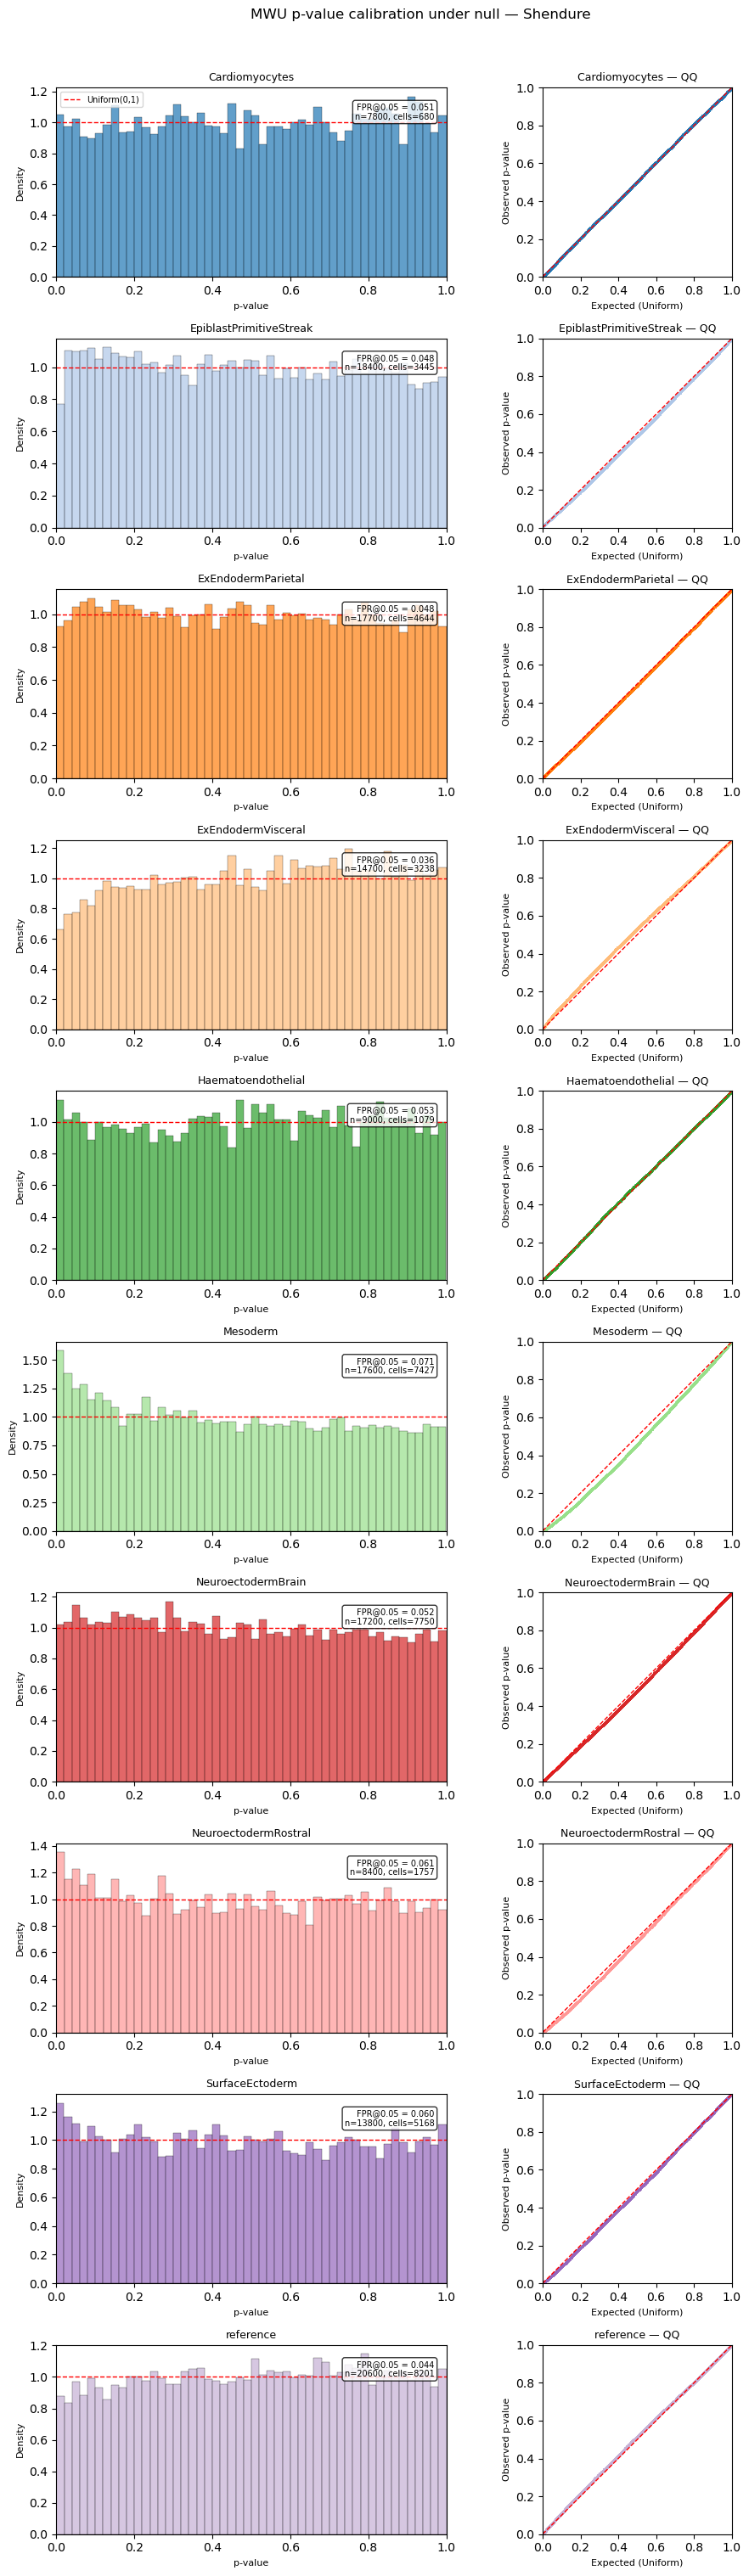

In [10]:
# --- Calibration plots: histograms + QQ, one row per cell type ---
from scipy.stats import uniform

ncols = 2  # histogram | QQ
nrows = len(cell_types)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
if nrows == 1:
    axes = axes[np.newaxis, :]

palette = sns.color_palette("tab20", n_colors=len(cell_types))

for i, ct in enumerate(cell_types):
    pvals = all_pvals[ct]
    pvals = pvals[np.isfinite(pvals)]  # drop NaN if any
    color = palette[i]
    fpr = np.mean(pvals < 0.05)
    cells = scm.SHENDURE_BOUNDS.cells_per_cell_type.get(ct, "?")

    # --- Histogram ---
    ax_h = axes[i, 0]
    ax_h.hist(pvals, bins=50, density=True, edgecolor="black",
              linewidth=0.3, alpha=0.7, color=color)
    ax_h.axhline(1.0, color="red", linestyle="--", lw=1, label="Uniform(0,1)")
    ax_h.set_title(f"{ct}", fontsize=9)
    ax_h.set_xlabel("p-value", fontsize=8)
    ax_h.set_ylabel("Density", fontsize=8)
    ax_h.set_xlim(0, 1)
    ax_h.text(
        0.97, 0.92,
        f"FPR@0.05 = {fpr:.3f}\nn={len(pvals)}, cells={cells}",
        transform=ax_h.transAxes, ha="right", va="top", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    if i == 0:
        ax_h.legend(fontsize=7, loc="upper left")

    # --- QQ plot ---
    ax_q = axes[i, 1]
    observed = np.sort(pvals)
    n = len(observed)
    expected = uniform.ppf(np.linspace(0, 1, n + 2)[1:-1])
    ax_q.scatter(expected, observed, s=1, alpha=0.5, color=color)
    ax_q.plot([0, 1], [0, 1], "r--", lw=1)
    ax_q.set_title(f"{ct} — QQ", fontsize=9)
    ax_q.set_xlabel("Expected (Uniform)", fontsize=8)
    ax_q.set_ylabel("Observed p-value", fontsize=8)
    ax_q.set_xlim(0, 1)
    ax_q.set_ylim(0, 1)
    ax_q.set_aspect("equal")

fig.suptitle("MWU p-value calibration under null — Shendure", fontsize=12, y=1.01)
plt.tight_layout()
svg_path = output_dir / "calibration_mwu_all_cell_types.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
print(f"Saved: {svg_path}")
plt.show()

In [11]:
client.close()
cluster.close()